## 1. Import Required Libraries

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, auc,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif, chi2
import warnings
import time
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import joblib
from collections import defaultdict

# Suppress warnings
warnings.filterwarnings('ignore')

# Set display options and plot style
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 2.1 Load the Dataset

In [145]:
# Load the dataset (CICIDS2017)
file_path = r'C:\Users\amity\SentinelNet\data\CICIDS2017\Wednesday-workingHours.pcap_ISCX.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except:
    try:
        df = pd.read_csv(file_path, encoding='latin-1')
    except:
        df = pd.read_csv(file_path, encoding='iso-8859-1')

# Display basic info
df.shape, df.columns


((692703, 79),
 Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Fl

## 2.2 Initial Data Exploration

In [146]:
# Display first few rows
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,6,6,6.000000,0.000000,3.132505e+02,52.208416,38308.000000,0.000000,38308,38308,0,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0,0,0,0,0,20,20,26.104208,26.104208,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.000000,20,0,0,0,0,0,0,1,6,1,6,255,946,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,163,0,65.200000,89.278777,1.039666e+06,33402.922760,31.933333,25.510409,73,0,479,47.900000,38.942836,109,1,401,100.250000,101.736178,237,3,0,0,0,0,368,176,22964.509390,10438.413360,0,163,29.294118,56.529599,3195.595588,0,0,0,1,0,0,0,0,0,31.125000,15.636364,65.200000,368,0,0,0,0,0,0,11,172,5,326,29200,260,4,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,1575,0,525.000000,813.326503,5.753425e+06,14611.872150,73.000000,204.960972,810,1,1095,121.666667,298.746130,915,1,995,199.000000,345.535092,810,3,0,0,0,0,336,208,9132.420091,5479.452055,0,1575,370.588235,671.751541,451250.132400,0,0,0,1,0,0,0,0,0,393.750000,315.000000,525.000000,336,0,0,0,0,0,0,10,3150,6,3150,29200,2081,3,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,3069,0,555.000000,977.480342,6.650007e+05,1907.141918,543.071429,2519.931377,13391,0,15206,950.375000,3322.417812,13391,2,15112,1373.818182,4176.449588,13961,3,0,0,0,0,560,388,1117.979745,789.162173,0,3069,337.066667,704.654082,496537.374700,0,0,0,1,0,0,0,0,0,348.689655,203.058823,555.000000,560,0,0,0,0,0,0,17,3452,12,6660,29200,0,10,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,1576,0,525.333333,813.842901,5.771062e+06,13736.263740,78.000000,207.000929,794,1,1092,136.500000,313.850738,910,1,1015,203.000000,333.240154,794,3,0,0,0,0,304,208,8241.758242,5494.505495,0,1576,393.875000,704.585067,496440.116700,0,0,0,1,0,0,0,0,0,420.133333,350.000000,525.333333,304,0,0,0,0,0,0,9,3150,6,3152,29200,2081,2,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [147]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-nul

## 2.3 Identify and Analyze Target Variable

In [148]:
# Identify label column
label_col = ' Label' if ' Label' in df.columns else 'Label' if 'Label' in df.columns else df.columns[-1]

# Class distribution
label_dist = df[label_col].value_counts()
label_dist_pct = df[label_col].value_counts(normalize=True) * 100

label_dist, label_dist_pct.round(2)


( Label
 BENIGN              440031
 DoS Hulk            231073
 DoS GoldenEye        10293
 DoS slowloris         5796
 DoS Slowhttptest      5499
 Heartbleed              11
 Name: count, dtype: int64,
  Label
 BENIGN              63.52
 DoS Hulk            33.36
 DoS GoldenEye        1.49
 DoS slowloris        0.84
 DoS Slowhttptest     0.79
 Heartbleed           0.00
 Name: proportion, dtype: float64)


📊 Normal vs Attack Distribution (Binary)


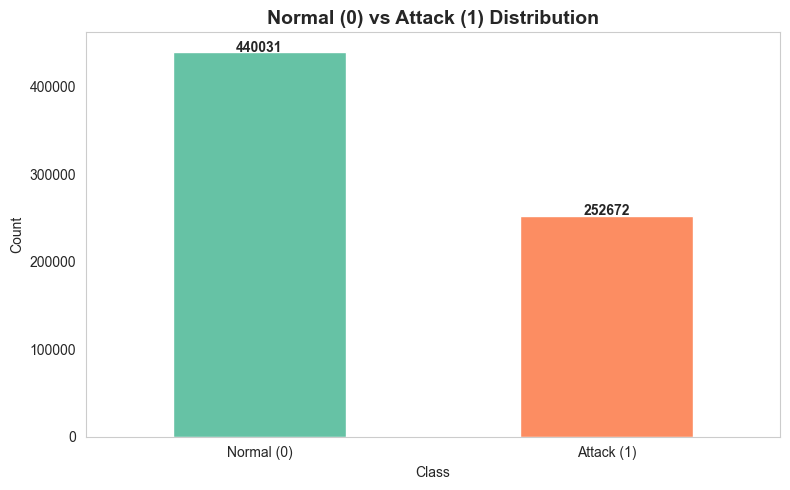

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Normal vs Attack Distribution ---
print("\n📊 Normal vs Attack Distribution (Binary)")
print("="*80)

# Convert to binary
y_binary = df[label_col].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Use Set2 palette with 2 colors
colors = sns.color_palette("Set2", 2)

# Plot Normal vs Attack
plt.figure(figsize=(8,5))
y_binary.value_counts().plot(kind='bar', color=colors)
plt.grid(False)
plt.title('Normal (0) vs Attack (1) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0,1], ['Normal (0)', 'Attack (1)'], rotation=0)


# Add value labels
for i, v in enumerate(y_binary.value_counts().values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



📊 Top 10 Attack Types (Multi-class)


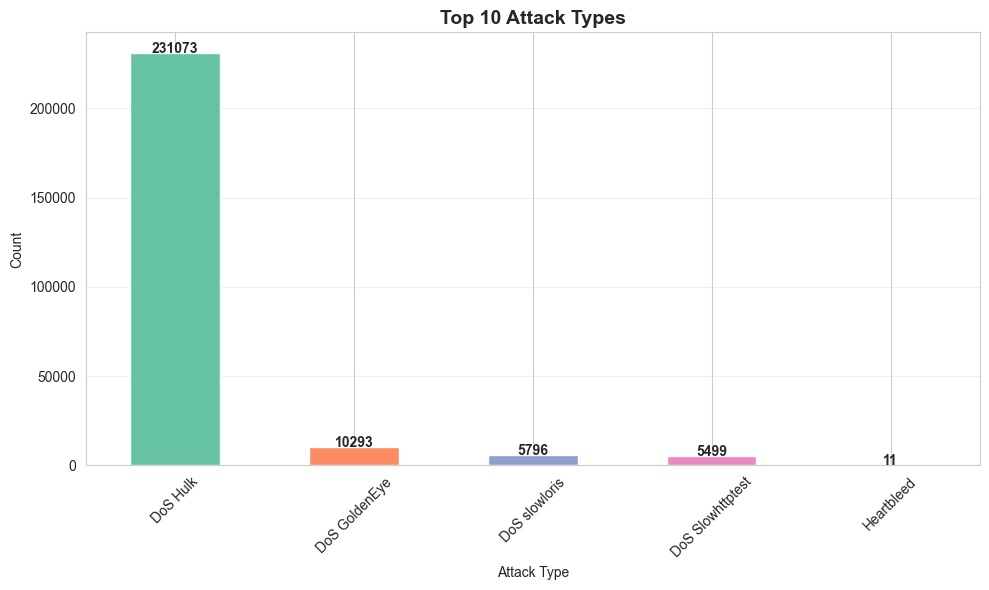

In [150]:
# --- Top 10 Attack Types (Multi-class) ---
print("\n📊 Top 10 Attack Types (Multi-class)")
print("="*80)

# Exclude 'BENIGN' to show only attacks
attack_types = df[label_col][df[label_col] != 'BENIGN'].value_counts().head(10)

plt.figure(figsize=(10,6))
attack_types.plot(kind='bar', color=sns.color_palette("Set2", n_colors=10))
plt.title('Top 10 Attack Types', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(attack_types.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Class Distribution (Count) – Bar Chart

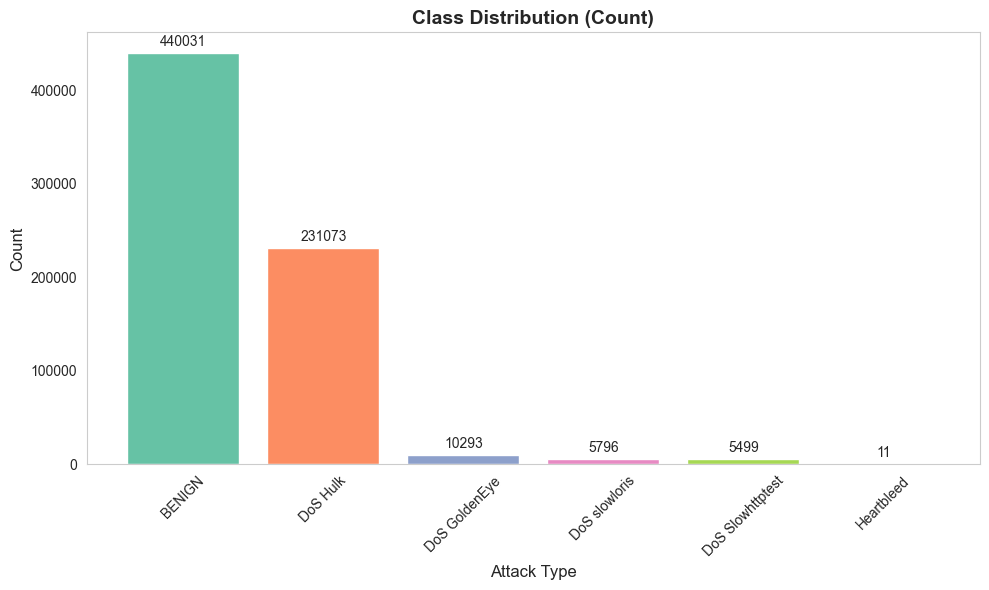

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette("Set2", n_colors=len(label_dist))

plt.figure(figsize=(10,6))
bars = plt.bar(label_dist.index, label_dist.values, color=colors)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(label_dist.values),
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Class Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Remove grid
plt.grid(False)

plt.tight_layout()
plt.show()


## Class Distribution (Percentage) – Pie Chart

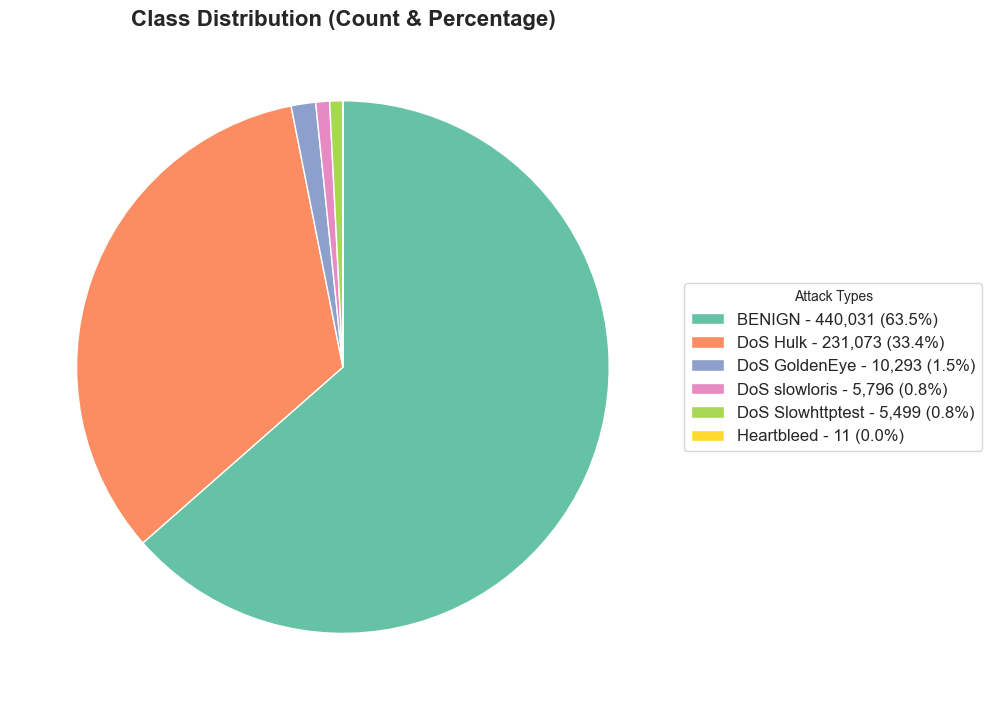

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette("Set2", n_colors=len(label_dist))

plt.figure(figsize=(10,10))

# Draw pie chart without labels inside
wedges, texts = plt.pie(
    label_dist.values,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)

# Add a legend outside with labels and percentages
labels_with_pct = [f"{l} - {v:,} ({v/sum(label_dist.values)*100:.1f}%)" 
                   for l, v in zip(label_dist.index, label_dist.values)]
plt.legend(wedges, labels_with_pct,
           title="Attack Types",
           loc="center left",
           bbox_to_anchor=(1, 0.5),
           fontsize=12)

plt.title('Class Distribution (Count & Percentage)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 2.4 Check Data Quality

In [153]:
# Missing values
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Percentage': missing_pct.values
})
missing_summary[missing_summary['Missing_Count'] > 0]


,Column,Missing_Count,Percentage
14,Flow Bytes/s,1008,0.145517


In [154]:
# Infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum()
inf_count[inf_count > 0]

Flow Bytes/s        289
 Flow Packets/s    1297
dtype: int64

In [155]:
# Duplicate rows
df.duplicated().sum()

81909

<!-- EXPE -->

# 3. Data Preprocessing

In [156]:
# --- 3.1 Handle Missing and Infinite Values ---

# Create a copy for preprocessing
df_processed = df.copy()

numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
categorical_columns = df_processed.select_dtypes(include=['object']).columns

# Track changes
missing_fixed = 0
infinite_fixed = 0

# Fill numeric columns with median
for col in numeric_columns:
    num_missing = df_processed[col].isnull().sum()
    if num_missing > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
        missing_fixed += num_missing
        print(f" Filled {num_missing} missing values in numeric column '{col}' with median")

# Fill categorical columns with mode
for col in categorical_columns:
    if col != label_col:
        num_missing = df_processed[col].isnull().sum()
        if num_missing > 0:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
            missing_fixed += num_missing
            print(f" Filled {num_missing} missing values in categorical column '{col}' with mode")

# Handle infinite values
for col in numeric_columns:
    num_inf = np.isinf(df_processed[col]).sum()
    if num_inf > 0:
        max_val = df_processed[col][np.isfinite(df_processed[col])].max()
        df_processed[col] = df_processed[col].replace([np.inf, -np.inf], max_val)
        infinite_fixed += num_inf
        print(f" Replaced {num_inf} infinite values in column '{col}' with max finite value {max_val}")

print(f"\n Preprocessing Complete: {missing_fixed} missing values fixed, {infinite_fixed} infinite values fixed")


 Filled 1008 missing values in numeric column 'Flow Bytes/s' with median
 Replaced 289 infinite values in column 'Flow Bytes/s' with max finite value 2070000000.0
 Replaced 1297 infinite values in column ' Flow Packets/s' with max finite value 3000000.0

 Preprocessing Complete: 1008 missing values fixed, 1586 infinite values fixed


In [157]:
# --- 3.2 Remove Duplicates and Encode Categorical Features ---

# Remove duplicate rows
initial_rows = len(df_processed)
df_processed = df_processed.drop_duplicates()
removed_duplicates = initial_rows - len(df_processed)
print(f" Removed {removed_duplicates} duplicate rows. Remaining rows: {len(df_processed)}")


 Removed 81909 duplicate rows. Remaining rows: 610794


In [158]:
# Encode categorical features (except target)
categorical_features = [col for col in categorical_columns if col != label_col]
if categorical_features:
    for col in categorical_features:
        df_processed[col] = LabelEncoder().fit_transform(df_processed[col].astype(str))
    print(f"✅ Encoded {len(categorical_features)} categorical features: {categorical_features}")
else:
    print(" No categorical features to encode")

 No categorical features to encode


In [159]:
# --- 3.3 Prepare Features and Target ---

X = df_processed.drop(columns=[label_col])
y = df_processed[label_col]

print(f" Features shape: {X.shape}")
print(f" Target shape: {y.shape}")

# Convert to binary classification
y_binary = y.apply(lambda x: 0 if x == 'BENIGN' else 1)

# Print class distribution
print(f" Binary Conversion Complete:")
print(f"   • Class 0 (Benign): {(y_binary==0).sum():,} samples")
print(f"   • Class 1 (Attack): {(y_binary==1).sum():,} samples")
print(f"   • Imbalance Ratio (Attack:Benign): {(y_binary==1).sum() / (y_binary==0).sum():.2f}:1")


 Features shape: (610794, 78)
 Target shape: (610794,)
 Binary Conversion Complete:
   • Class 0 (Benign): 417,035 samples
   • Class 1 (Attack): 193,759 samples
   • Imbalance Ratio (Attack:Benign): 0.46:1


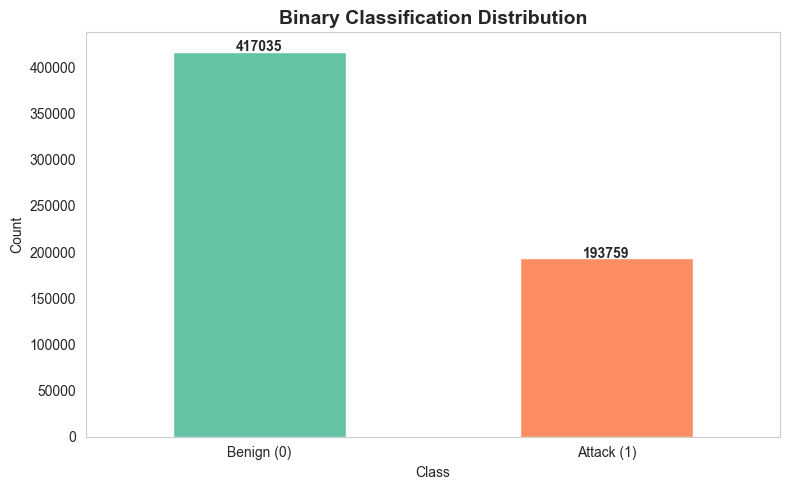

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use Set2 palette
colors = sns.color_palette("Set2", n_colors=2)

plt.figure(figsize=(8, 5))
y_binary.value_counts().plot(kind='bar', color=colors)
plt.title('Binary Classification Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign (0)', 'Attack (1)'], rotation=0)
plt.grid(False)

# Add value labels on bars
for i, v in enumerate(y_binary.value_counts().values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [161]:
# --- 3.4 Feature Engineering ---

# Remove constant features
constant_features = [col for col in X.columns if X[col].nunique() == 1]
X = X.drop(columns=constant_features) if constant_features else X

# Remove highly correlated features (corr > 0.95)
corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
X = X.drop(columns=to_drop)


In [162]:
# --- 3.5 Feature Selection using ANOVA F-Test ---

k_features = min(30, X.shape[1])
selector = SelectKBest(f_classif, k=k_features)
X_selected = selector.fit_transform(X, y_binary)

# Selected features and scores
selected_features = X.columns[selector.get_support()].tolist()
feature_scores = selector.scores_[selector.get_support()]

feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Score': feature_scores
}).sort_values('Score', ascending=False)

# Print selected features and scores
print("Selected Features and their ANOVA F-Scores:")
print(feature_importance_df.to_string(index=False))


Selected Features and their ANOVA F-Scores:
                 Feature         Score
   Bwd Packet Length Max 983931.826610
      Packet Length Mean 839440.351627
            Flow IAT Std 654290.870652
  Packet Length Variance 637845.399362
           Flow Duration 402506.806734
           Flow IAT Mean 188614.261266
            Fwd IAT Mean 187043.428713
          FIN Flag Count 149997.371762
   Bwd Packet Length Min  99443.468941
             Bwd IAT Std  86990.867637
       Min Packet Length  79043.731767
             Bwd IAT Max  75694.612562
        Destination Port  44566.973236
          ACK Flag Count  40474.327106
   Fwd Packet Length Min  36807.973935
          URG Flag Count  19856.086000
           Bwd IAT Total  18434.680043
           Down/Up Ratio  16772.220306
            Bwd IAT Mean  15027.747769
          Flow Packets/s   9937.390100
 Init_Win_bytes_backward   8794.936924
           Fwd Packets/s   8769.052304
                Idle Std   8178.383893
           Fwd PSH F

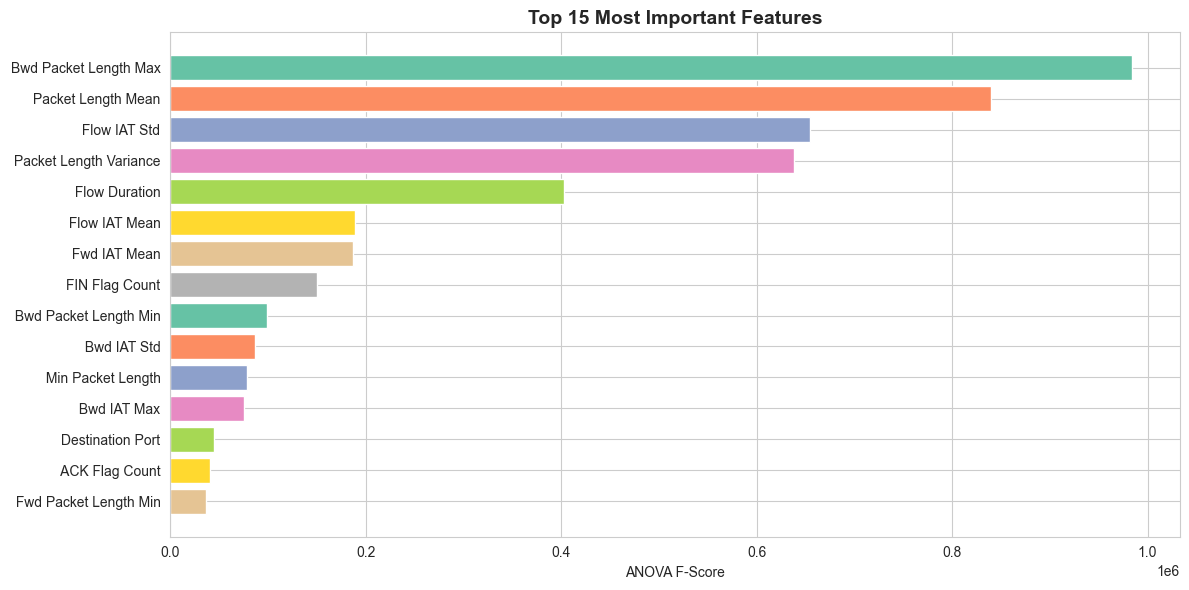

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use Set2 palette
colors = sns.color_palette("Set2", n_colors=15)

# Plot top 15 features
plt.figure(figsize=(12, 6))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Score'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('ANOVA F-Score')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # highest score on top
plt.tight_layout()
plt.show()


In [183]:
import os
import joblib
import pandas as pd

# Make sure folder exists
save_path = r'C:\Users\amity\SentinelNet\data\processed\cicids2017'
os.makedirs(save_path, exist_ok=True)

# 1️⃣ Save df_processed (after cleaning + encoding)
df_processed.to_csv(os.path.join(save_path, 'cicids2017_processed.csv'), index=False)

# 2️⃣ Save X_selected and y_binary (after feature selection)
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df['Label'] = y_binary.values
X_selected_df.to_csv(os.path.join(save_path, 'X_selected.csv'), index=False)

# 3️⃣ Optionally save NumPy arrays for ML (fast loading later)
joblib.dump(X_selected, os.path.join(save_path, 'X_selected.pkl'))
joblib.dump(y_binary.values, os.path.join(save_path, 'y_binary.pkl'))

print("✅ Preprocessed and selected data saved successfully in:")
print(save_path)


✅ Preprocessed and selected data saved successfully in:
C:\Users\amity\SentinelNet\data\processed\cicids2017


<!--  -->

# 4. Data Splitting and Balancing

## 4.1 Train-Validation-Test Split

In [165]:
print(" Data Splitting Strategy")
print("="*80)

# First split: Train+Val (80%) and Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Second split: Train (70% of 80% = 56%) and Validation (30% of 80% = 24%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(" Data Split Complete!")
print(f"\n Dataset Sizes:")
print(f"   • Training Set:   {X_train.shape[0]:,} samples ({(len(X_train)/len(X_selected))*100:.1f}%)")
print(f"   • Validation Set: {X_val.shape[0]:,} samples ({(len(X_val)/len(X_selected))*100:.1f}%)")
print(f"   • Test Set:       {X_test.shape[0]:,} samples ({(len(X_test)/len(X_selected))*100:.1f}%)")

print(f"\n Class Distribution in Sets:")
print(f"   • Train - Benign: {(y_train==0).sum():,}, Attack: {(y_train==1).sum():,}")
print(f"   • Val   - Benign: {(y_val==0).sum():,}, Attack: {(y_val==1).sum():,}")
print(f"   • Test  - Benign: {(y_test==0).sum():,}, Attack: {(y_test==1).sum():,}")

 Data Splitting Strategy
 Data Split Complete!

 Dataset Sizes:
   • Training Set:   342,044 samples (56.0%)
   • Validation Set: 146,591 samples (24.0%)
   • Test Set:       122,159 samples (20.0%)

 Class Distribution in Sets:
   • Train - Benign: 233,539, Attack: 108,505
   • Val   - Benign: 100,089, Attack: 46,502
   • Test  - Benign: 83,407, Attack: 38,752


⚖️ Handling Class Imbalance

📊 Original Training Set Distribution:
   • Benign: 233,539
   • Attack: 108,505
   • Ratio: 1:0.46

🔄 Applying Random UnderSampling...

✅ Balanced Training Set Distribution:
   • Benign: 217,010
   • Attack: 108,505
   • Ratio: 1:0.50


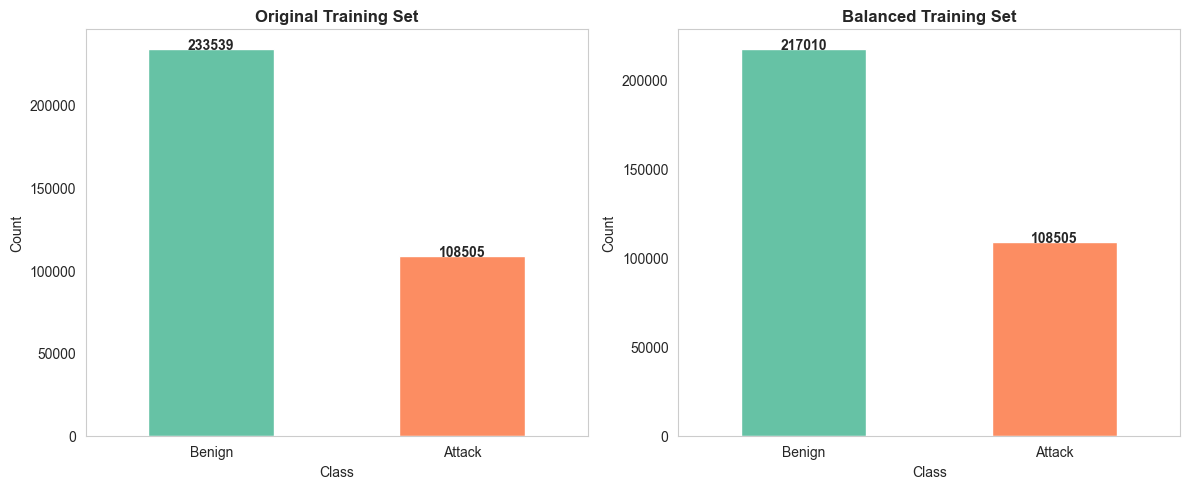

In [166]:
# --- 4.2 Handle Class Imbalance ---

import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Display original distribution
print("⚖️ Handling Class Imbalance")
print("="*80)

print(f"\n📊 Original Training Set Distribution:")
print(f"   • Benign: {(y_train==0).sum():,}")
print(f"   • Attack: {(y_train==1).sum():,}")
print(f"   • Ratio: 1:{((y_train==1).sum()/(y_train==0).sum()):.2f}")

# Apply undersampling for faster training
print("\n🔄 Applying Random UnderSampling...")
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

print(f"\n✅ Balanced Training Set Distribution:")
print(f"   • Benign: {(y_train_balanced==0).sum():,}")
print(f"   • Attack: {(y_train_balanced==1).sum():,}")
print(f"   • Ratio: 1:{((y_train_balanced==1).sum()/(y_train_balanced==0).sum()):.2f}")

# Visualize the balancing effect
colors = sns.color_palette("Set2", n_colors=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original distribution
y_train.value_counts().plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Original Training Set', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Benign', 'Attack'], rotation=0)
ax1.grid(False)  # Remove grid
for i, v in enumerate(y_train.value_counts().values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Balanced distribution
pd.Series(y_train_balanced).value_counts().plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Balanced Training Set', fontsize=12, fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')
ax2.set_xticklabels(['Benign', 'Attack'], rotation=0)
ax2.grid(False)  # Remove grid
for i, v in enumerate(pd.Series(y_train_balanced).value_counts().values):
    ax2.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


<!--  -->

In [167]:
## 4.3 Feature Scaling

print("📏 Feature Scaling")
print("="*80)

print("\n Applying StandardScaler...")

# Initialize and fit scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled successfully!")
print(f"\n Scaled Data Statistics:")
print(f"   • Mean ≈ 0: {np.abs(X_train_scaled.mean()).max():.6f}")
print(f"   • Std  ≈ 1: {X_train_scaled.std().mean():.6f}")


# ---


📏 Feature Scaling

 Applying StandardScaler...
 Features scaled successfully!

 Scaled Data Statistics:
   • Mean ≈ 0: 0.000000
   • Std  ≈ 1: 1.000000


# 5. Model Training and Evaluatio

## 5.1 Initialize Models

In [168]:
print(" Initializing Machine Learning Models")
print("="*80)

# Define models with optimized hyperparameters
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        solver='saga',
        C=1.0,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42
    ),
    
    'Histogram Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.2
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

print(" Models initialized with optimized hyperparameters")
print(f"\n Models to train: {list(models.keys())}")


 Initializing Machine Learning Models
 Models initialized with optimized hyperparameters

 Models to train: ['Logistic Regression', 'Decision Tree', 'Histogram Gradient Boosting', 'Random Forest']


## 5.2 Train Models and Evaluate

In [169]:
# Store results
results = {}
training_history = defaultdict(dict)

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    # Training time
    start_time = time.time()
    
    # Train model
    model.fit(X_train_scaled, y_train_balanced)
    
    # Training time
    train_time = time.time() - start_time
    
    # Get predictions and probabilities
    y_train_pred = model.predict(X_train_scaled)
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    train_acc = accuracy_score(y_train_balanced, y_train_pred)
    
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    val_acc = accuracy_score(y_val, y_val_pred)
    
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Metrics
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    auc_score = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None
    
    # Store results
    results[model_name] = {
        'model': model,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'train_time': train_time,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba,
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba,
        'auc': auc_score,
        'tpr': tpr,
        'tnr': tnr,
        'fpr': fpr,
        'fnr': fnr
    }
    
    # Display results
    print(f"\n Training Time: {train_time:.2f} seconds")
    print(f"\n ACCURACY SCORES:")
    print(f"   • Training Accuracy:   {train_acc*100:.2f}%")
    print(f"   • Validation Accuracy: {val_acc*100:.2f}%")
    print(f"   • Test Accuracy:       {test_acc*100:.2f}%")
    



Training: Logistic Regression

 Training Time: 294.46 seconds

 ACCURACY SCORES:
   • Training Accuracy:   98.00%
   • Validation Accuracy: 97.99%
   • Test Accuracy:       98.00%

Training: Decision Tree

 Training Time: 8.73 seconds

 ACCURACY SCORES:
   • Training Accuracy:   99.54%
   • Validation Accuracy: 99.53%
   • Test Accuracy:       99.54%

Training: Histogram Gradient Boosting

 Training Time: 6.19 seconds

 ACCURACY SCORES:
   • Training Accuracy:   99.95%
   • Validation Accuracy: 99.95%
   • Test Accuracy:       99.96%

Training: Random Forest

 Training Time: 27.62 seconds

 ACCURACY SCORES:
   • Training Accuracy:   99.93%
   • Validation Accuracy: 99.93%
   • Test Accuracy:       99.94%


In [184]:
import os
import joblib

# Directory to save models for Streamlit app
save_dir = r"C:\Users\amity\SentinelNet\app\models\cicids2017"
os.makedirs(save_dir, exist_ok=True)

# Save each trained model
for name, data in results.items():
    model = data['model']
    filename = os.path.join(save_dir, f"{name.replace(' ', '_').lower()}.pkl")
    joblib.dump(model, filename)
    print(f"✅ Saved: {filename}")

# Save the scaler (important for Streamlit input preprocessing)
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
print("✅ Scaler saved")


✅ Saved: C:\Users\amity\SentinelNet\app\models\cicids2017\logistic_regression.pkl
✅ Saved: C:\Users\amity\SentinelNet\app\models\cicids2017\decision_tree.pkl
✅ Saved: C:\Users\amity\SentinelNet\app\models\cicids2017\histogram_gradient_boosting.pkl
✅ Saved: C:\Users\amity\SentinelNet\app\models\cicids2017\random_forest.pkl
✅ Scaler saved


<!-- hwiucdisu bjwechdsj b -->

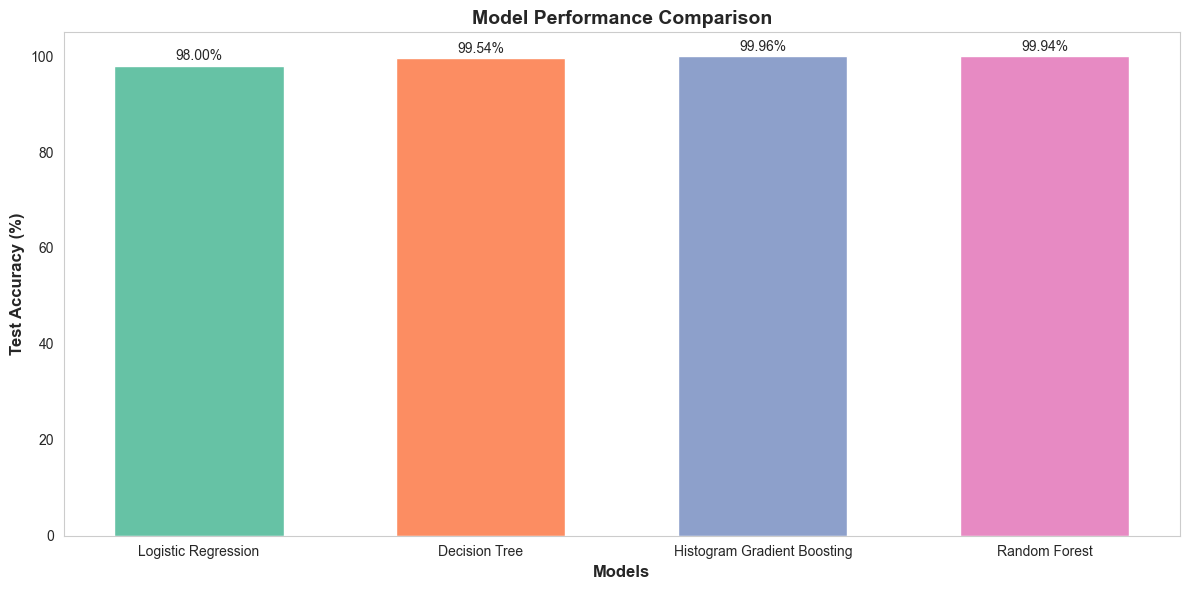

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
models_list = list(results.keys())
test_accs = [results[m]['test_acc']*100 for m in models_list]

# Use Set2 color palette
colors = sns.color_palette("Set2", n_colors=len(models_list))

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(models_list, test_accs, color=colors, width=0.6)

plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(False)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Increase top limit to fit labels above tallest bar
plt.ylim(0, max(test_accs) + 5)

plt.tight_layout()
plt.show()


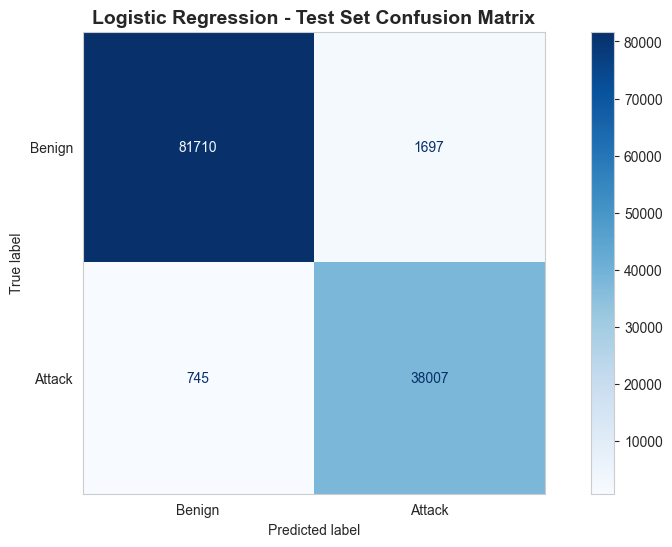

In [172]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_name = 'Logistic Regression'
cm = results[model_name]['confusion_matrix']

# Display confusion matrix with counts only
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d')
plt.grid(False)
plt.title(f'{model_name} - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


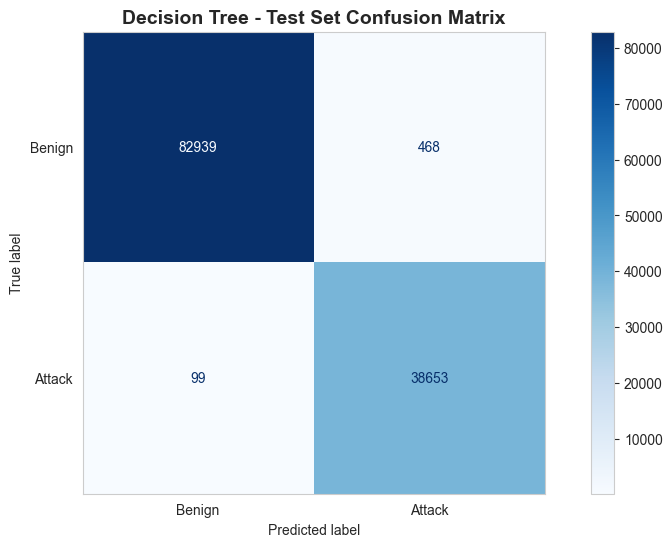

In [173]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_name = 'Decision Tree'
cm = results[model_name]['confusion_matrix']

# Display confusion matrix with counts only
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d')
plt.grid(False)
plt.title(f'{model_name} - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


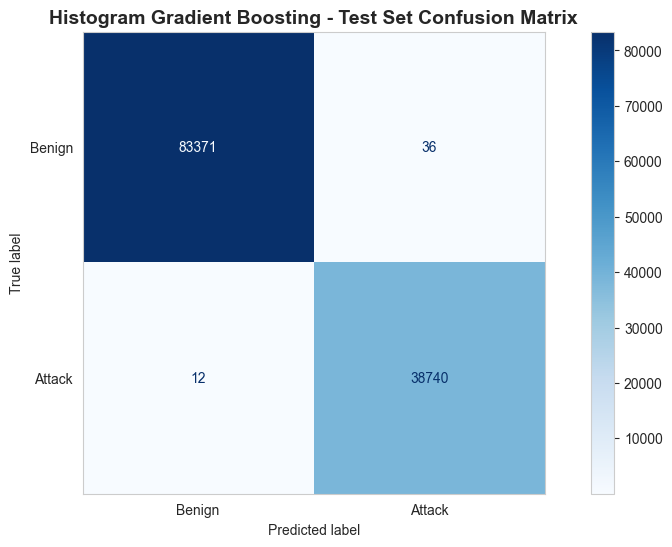

In [174]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_name = 'Histogram Gradient Boosting'
cm = results[model_name]['confusion_matrix']

# Display confusion matrix with counts only
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d')
plt.grid(False)
plt.title(f'{model_name} - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


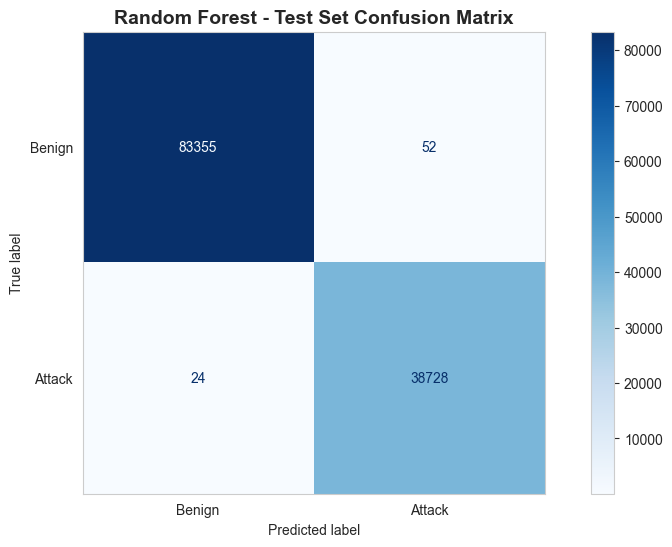

In [175]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_name = 'Random Forest'
cm = results[model_name]['confusion_matrix']

# Display confusion matrix with counts only
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d')
plt.grid(False)
plt.title(f'{model_name} - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


📊 Combined Predicted Probabilities Box Plot for Test Set


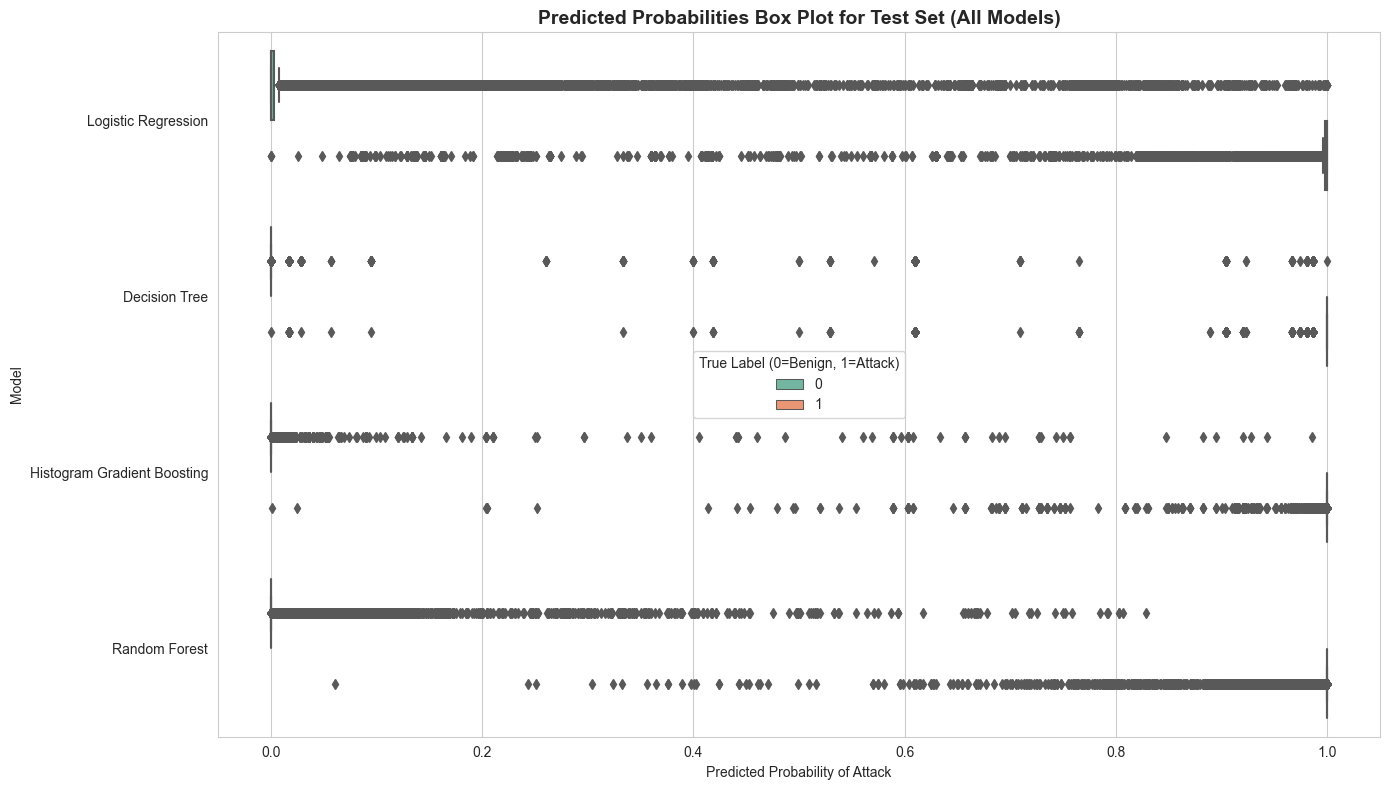

In [176]:
print("📊 Combined Predicted Probabilities Box Plot for Test Set")
print("="*80)

plot_data = []

# Collect probability predictions from all models
for model_name, model_info in results.items():
    y_test_proba = model_info['y_test_proba']
    for true, pred in zip(y_test, y_test_proba):
        plot_data.append([model_name, true, pred])

# Convert to DataFrame
proba_df = pd.DataFrame(plot_data, columns=["Model", "True Label", "Predicted Probability"])

plt.figure(figsize=(14, 8))
sns.boxplot(
    x="Predicted Probability", 
    y="Model", 
    hue="True Label", 
    data=proba_df, 
    orient="h", 
    palette="Set2"
)
plt.title("Predicted Probabilities Box Plot for Test Set (All Models)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Probability of Attack")
plt.ylabel("Model")
plt.legend(title="True Label (0=Benign, 1=Attack)")
plt.tight_layout()
plt.show()


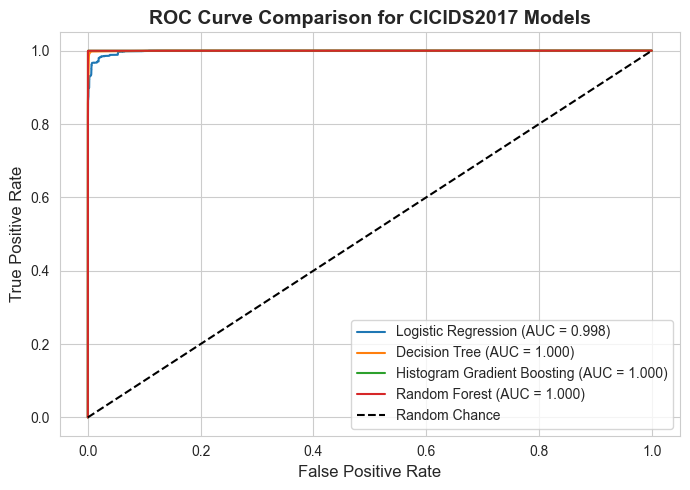

In [177]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for model_name, model_info in results.items():
    y_probs = model_info['y_test_proba']
    if y_probs is not None:
        # Compute ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        auc_score = roc_auc_score(y_test, y_probs)
        
        # Plot ROC
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curve Comparison for CICIDS2017 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [178]:
print(df.columns.tolist())


[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

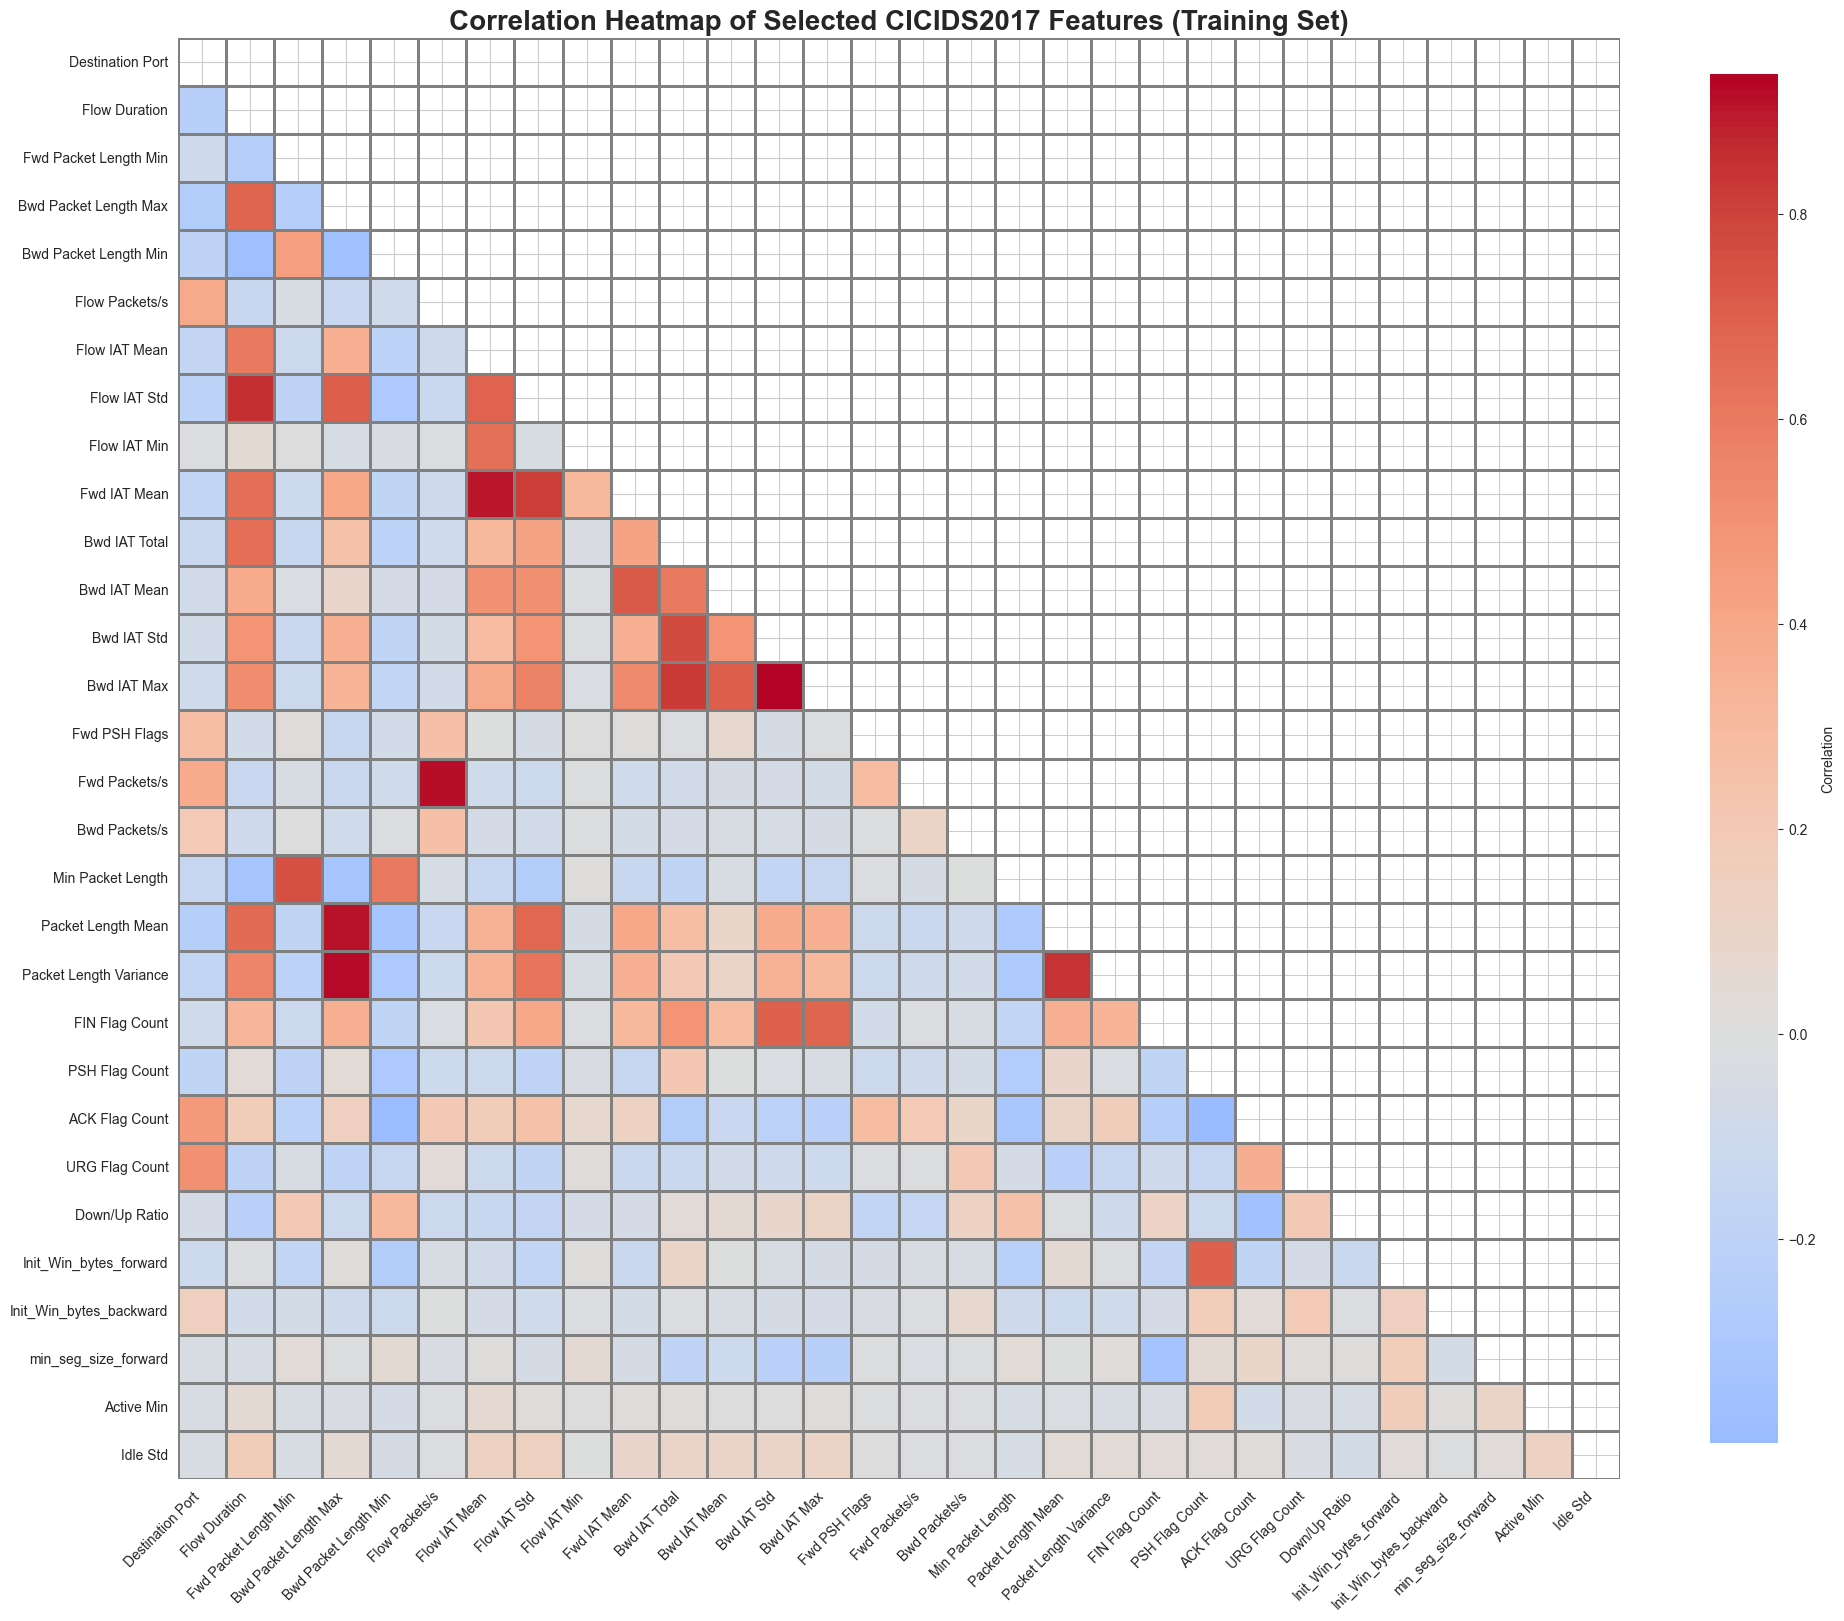

In [179]:
# Convert X_train numpy array to DataFrame with selected feature names
X_train_df = pd.DataFrame(X_train, columns=selected_features)

# Compute correlation matrix
corr_matrix = X_train_df.corr()

# Mask upper triangle to reduce clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,                  # Set True if you want numeric values
    linewidths=0.8,
    linecolor='gray',
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    square=True
)

# Use actual feature names for x and y axes
plt.xticks(ticks=np.arange(len(corr_matrix.columns)) + 0.5,
           labels=[c.strip() for c in corr_matrix.columns],
           rotation=45, ha='right', fontsize=10)
plt.yticks(ticks=np.arange(len(corr_matrix.columns)) + 0.5,
           labels=[c.strip() for c in corr_matrix.columns],
           rotation=0, fontsize=10)

plt.title("Correlation Heatmap of Selected CICIDS2017 Features (Training Set)",
          fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()


In [180]:
import pandas as pd

# Prepare clean comparison table
comparison_data = []
for model_name, metrics in results.items():
    tn, fp, fn, tp = metrics['confusion_matrix'].ravel()
    tpr = metrics['tpr']  # Sensitivity / Recall
    tnr = metrics['tnr']  # Specificity
    
    comparison_data.append({
        'Model': model_name,
        'Train Accuracy (%)': metrics['train_acc']*100,
        'Validation Accuracy (%)': metrics['val_acc']*100,
        'Test Accuracy (%)': metrics['test_acc']*100,
        'Sensitivity (Recall)': tpr,
        'Specificity': tnr,
        'Precision': metrics['precision'],
        'F1-Score': metrics['f1'],
        'AUC': metrics['auc'] if metrics['auc'] else None
    })

comparison_df = pd.DataFrame(comparison_data)

# Style the table for notebook display
styled_df = (comparison_df.style
             .format({
                 'Train Accuracy (%)': '{:.2f}%',
                 'Validation Accuracy (%)': '{:.2f}%',
                 'Test Accuracy (%)': '{:.2f}%',
                 'Sensitivity (Recall)': '{:.4f}',
                 'Specificity': '{:.4f}',
                 'Precision': '{:.4f}',
                 'F1-Score': '{:.4f}',
                 'AUC': '{:.4f}'
             })
             .set_caption("📊 CICIDS2017 Model Performance Summary")
             .set_table_styles([
                 {'selector': 'th', 'props': [('background-color', '#4CAF50'),
                                               ('color', 'white'),
                                               ('font-weight', 'bold'),
                                               ('text-align', 'center')]},
                 {'selector': 'td', 'props': [('text-align', 'center')]}
             ])
             .hide(axis='index')  # <- Updated for new Pandas
            )

styled_df


Model,Train Accuracy (%),Validation Accuracy (%),Test Accuracy (%),Sensitivity (Recall),Specificity,Precision,F1-Score,AUC
Logistic Regression,98.00%,97.99%,98.00%,0.9808,0.9797,0.9803,0.9801,0.9983
Decision Tree,99.54%,99.53%,99.54%,0.9974,0.9944,0.9954,0.9954,0.9997
Histogram Gradient Boosting,99.95%,99.95%,99.96%,0.9997,0.9996,0.9996,0.9996,1.0000
Random Forest,99.93%,99.93%,99.94%,0.9994,0.9994,0.9994,0.9994,1.0000
